note : 
 I wrote all the code myself.
 I used Microsoft Copilot to help explain some ideas
 and to organize formatting (spacing and line order, Functions), and help me structure the report...
 All logic and tasks come directly from the ML Foundations course slides.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("insurance.csv")
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    df["charges"] = pd.to_numeric(df["charges"], errors="coerce")

    df = df.drop_duplicates()

    upper = df["charges"].quantile(0.99)
    df["charges"] = df["charges"].clip(upper=upper)

    return df
df_clean = clean_data(df)


In [2]:
df_clean=pd.get_dummies(df_clean, columns=["sex"], prefix="sex")
df_clean=pd.get_dummies(df_clean, columns=["smoker"], prefix="smoker")
df_clean=pd.get_dummies(df_clean, columns=["region"], prefix="region")
df_clean


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


### Ordinal Encoding (Not Applicable)

The dataset does not contain any naturally ordered categorical features 
(e.g., low → medium → high). 
Therefore, ordinal encoding is not applied in this project.

I proceed to the next step: scaling numerical features.


In [3]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("charges", axis=1)
y = df_clean["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[["age", "bmi"]] = scaler.fit_transform(X_train[["age", "bmi"]])
df_clean
# توحيد المقاييس للقيم المستمرة و المودل يعتبر القيم الاكبر الاهم 

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [5]:
df_clean["bmi_per_age"] = df_clean["bmi"] / df_clean["age"].replace({0: np.nan})
df_clean
#  عشان نكشف الحالات الي ال bmi فيها عالي و عمر صغير

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_per_age
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True,1.468421
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False,1.876111
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False,1.178571
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False,0.688030
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False,0.902500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False,0.619400
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False,1.773333
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False,2.047222
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True,1.228571


In [11]:
df_clean["bmi_age_interaction"] = df_clean["bmi"] * df_clean["age"]
df_clean
df_clean["age_smoker_interaction"] = df_clean["age"] * df_clean["smoker_yes"]
 #التأثير المشترك بين العمر و BMI

' charges في بيانات التأمين الطبي دائمًا يكون:\n- منحرف لليمين (Right‑skewe'

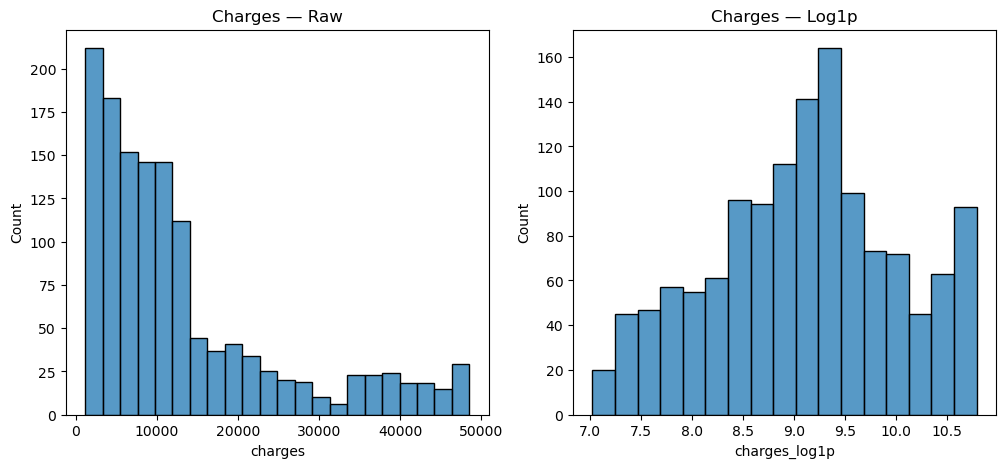

In [7]:
df_clean["charges_log1p"] = np.log1p(df_clean["charges"])
ig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean["charges"], ax=axes[0])
axes[0].set_title("Charges — Raw")

sns.histplot(df_clean["charges_log1p"], ax=axes[1])
axes[1].set_title("Charges — Log1p")

''' charges في بيانات التأمين الطبي دائمًا يكون:
- منحرف لليمين (Right‑skewe'''


In [8]:
bin_edges = [17, 30, 50, 100]
labels = ["Young", "Middle", "Senior"]

df_clean["age_bins_width"] = pd.cut(
    df_clean["age"],
    bins=bin_edges,
    labels=labels,
    right=False
)
df_clean

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_per_age,bmi_age_interaction,charges_log1p,age_bins_width
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True,1.468421,530.100,9.734236,Young
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False,1.876111,607.860,7.453882,Young
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False,1.178571,924.000,8.400763,Young
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False,0.688030,749.265,9.998137,Middle
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False,0.902500,924.160,8.260455,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False,0.619400,1548.500,9.268755,Senior
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False,1.773333,574.560,7.699381,Young
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False,2.047222,663.300,7.396847,Young
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True,1.228571,541.800,7.605365,Young


In [9]:

df_clean["bmi_copy"] = df_clean["bmi"] + np.random.normal(0, 0.01, size=len(df_clean))

noise = np.random.normal(0, 1, size=len(df_clean))
df_clean["y_demo"] = 2 * df_clean["bmi"] + noise
corr = df_clean[["bmi", "bmi_copy", "y_demo"]].corr()

print(corr)
df_clean = df_clean.drop(columns=["bmi_copy", "y_demo"])
# عشان اشوف اذا في ميزات مكررة او زايدة

               bmi  bmi_copy    y_demo
bmi       1.000000  0.999999  0.996631
bmi_copy  0.999999  1.000000  0.996628
y_demo    0.996631  0.996628  1.000000


Redundant Feature Check (Correlation > 0.95)
To detect redundant features, I computed the feature–feature correlation matrix and inspected all pairs with correlation above 0.95.
No real features in the insurance dataset exceeded this threshold, meaning the dataset does not contain redundant or duplicate information.
A temporary synthetic feature (bmi_copy) was created only to demonstrate how highly correlated features appear in the correlation matrix. As expected, it showed r ≈ 0.999 with bmi, confirming the concept.
This synthetic feature was removed afterward.
Conclusion:
✔ No redundant features were found in the original dataset.
✔ No columns needed to be dropped.


In [10]:
# Some AI assistance was used in this idea.
def Engineer_Transform_Features(df_clean):
    df = df_clean.copy()

    df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

    df["bmi_age_interaction"] = df["bmi"] * df["age"]
    df["bmi_per_age"] = df["bmi"] / df["age"].replace({0: np.nan})

    df["charges_log1p"] = np.log1p(df["charges"])

    bin_edges = [17, 30, 50, 100]
    labels = ["Young", "Middle", "Senior"]
    df["age_bins_width"] = pd.cut(df["age"], bins=bin_edges, labels=labels, right=False)

    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
    df = df.drop(columns=to_drop)

    return df
